Dataset shape: (5761, 60)
Labels shape: (5761,)
Class distribution: [3113 1408  796  444]

===== TRAINING Logistic Regression =====

Logistic Regression Accuracy: 0.6618
Logistic Regression F1 Score: 0.6506
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       623
           1       0.64      0.54      0.58       282
           2       0.59      0.52      0.55       159
           3       0.51      0.29      0.37        89

    accuracy                           0.66      1153
   macro avg       0.61      0.54      0.56      1153
weighted avg       0.65      0.66      0.65      1153



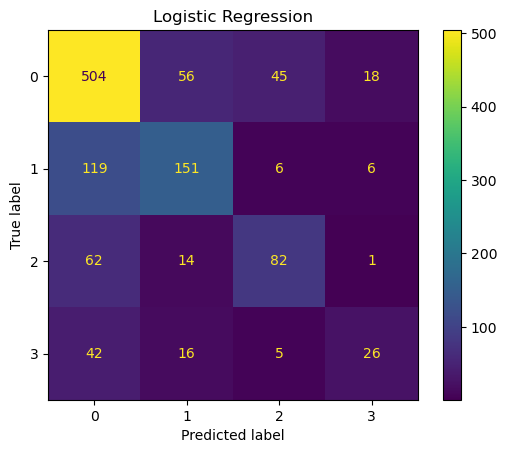


===== TRAINING SVM =====

SVM Accuracy: 0.8621
SVM F1 Score: 0.8602
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       623
           1       0.84      0.82      0.83       282
           2       0.93      0.81      0.87       159
           3       0.88      0.64      0.74        89

    accuracy                           0.86      1153
   macro avg       0.87      0.80      0.83      1153
weighted avg       0.86      0.86      0.86      1153



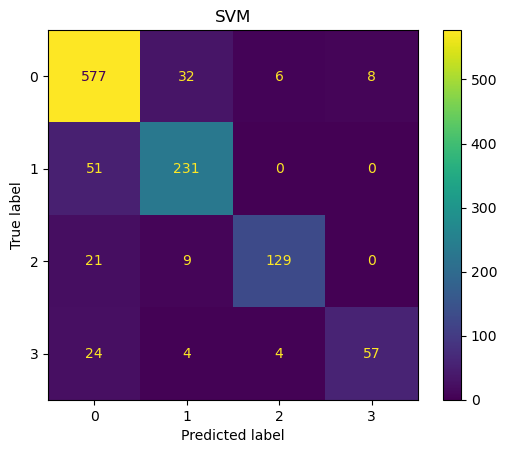


===== TRAINING KNN =====

KNN Accuracy: 0.9133
KNN F1 Score: 0.9131
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       623
           1       0.88      0.94      0.91       282
           2       0.88      0.96      0.92       159
           3       0.89      0.79      0.83        89

    accuracy                           0.91      1153
   macro avg       0.90      0.90      0.90      1153
weighted avg       0.91      0.91      0.91      1153



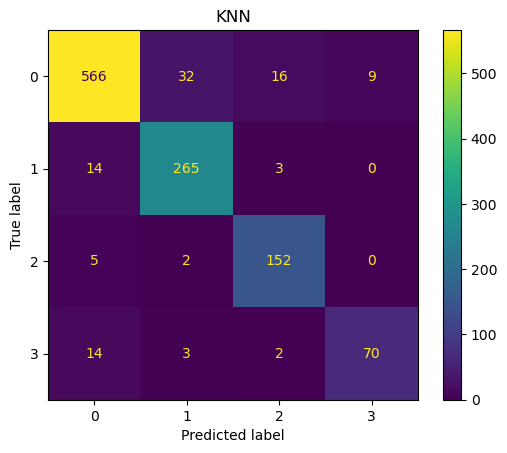


===== TRAINING Random Forest =====

Random Forest Accuracy: 0.9679
Random Forest F1 Score: 0.9677
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       623
           1       0.96      0.95      0.96       282
           2       0.99      0.97      0.98       159
           3       0.99      0.89      0.93        89

    accuracy                           0.97      1153
   macro avg       0.98      0.95      0.96      1153
weighted avg       0.97      0.97      0.97      1153



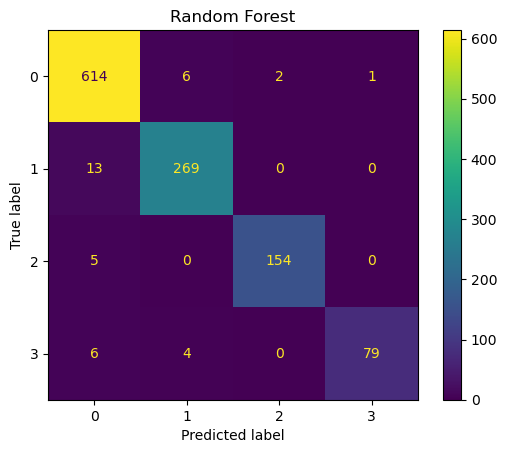


===== TRAINING Gradient Boosting =====

Gradient Boosting Accuracy: 0.9107
Gradient Boosting F1 Score: 0.9094
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       623
           1       0.90      0.86      0.88       282
           2       0.95      0.93      0.94       159
           3       0.96      0.72      0.82        89

    accuracy                           0.91      1153
   macro avg       0.93      0.87      0.89      1153
weighted avg       0.91      0.91      0.91      1153



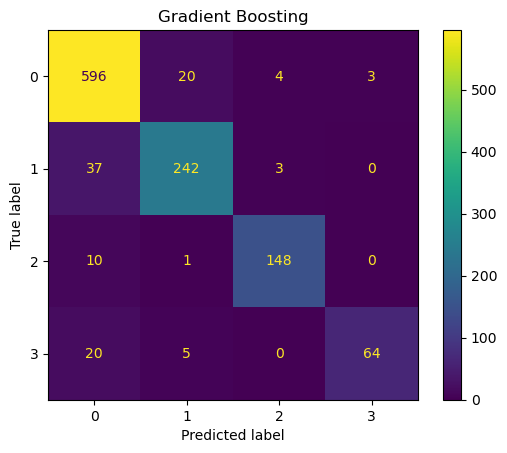


===== TRAINING XGBoost =====

XGBoost Accuracy: 0.9688
XGBoost F1 Score: 0.9685
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       623
           1       0.96      0.96      0.96       282
           2       0.98      0.98      0.98       159
           3       1.00      0.87      0.93        89

    accuracy                           0.97      1153
   macro avg       0.98      0.95      0.96      1153
weighted avg       0.97      0.97      0.97      1153



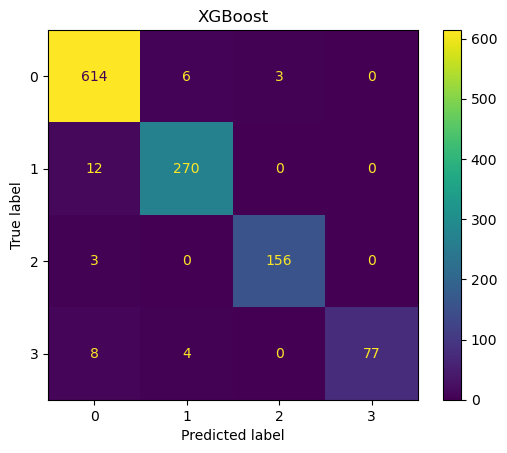


===== FINAL RESULTS =====
Logistic Regression | Accuracy: 0.6618 | F1: 0.6506
SVM | Accuracy: 0.8621 | F1: 0.8602
KNN | Accuracy: 0.9133 | F1: 0.9131
Random Forest | Accuracy: 0.9679 | F1: 0.9677
Gradient Boosting | Accuracy: 0.9107 | F1: 0.9094
XGBoost | Accuracy: 0.9688 | F1: 0.9685


In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

'''
These are all .py files that perform different functions and are imported into this main file to be used
'''

from pipelines.data_loader import load_all_subjects
from pipelines.feature_extraction import (
    create_windows,
    #create_raw_windows
)
from pipelines.evaluate import evaluate_model
from pipelines.logistics_pipeline import build_model as logistic_model
from pipelines.svm_pipeline import build_model as svm_model
from pipelines.randomforest_pipeline import build_model as rf_model
from pipelines.xgboost_pipeline import build_model as xgb_model
from pipelines.knn_pipeline import build_model as knn_model
from pipelines.gradientboost_pipeline import build_model as gb_model



#Like last time make sure the data is in WESAD/PX.pkl
DATA_DIR = 'data/WESAD'


#gets all the data from all the subjects
signals, labels = load_all_subjects(DATA_DIR)

all_X = []
all_y = []

for signal, label in zip(signals, labels):
    Xi, yi = create_windows(signal, label)

    all_X.extend(Xi)
    all_y.extend(yi)

all_X = np.array(all_X)
all_y = np.array(all_y)

print('Dataset shape:', all_X.shape)
print('Labels shape:', all_y.shape)
print('Class distribution:', np.bincount(all_y))

X_train, X_test, y_train, y_test = train_test_split(
    all_X,
    all_y,
    test_size=0.2,
    random_state=42,
    stratify=all_y
)


#all the different models/algorithms to be used, each using a method imported earlier
models = {
    'Logistic Regression': logistic_model(),
    'SVM': svm_model(),
    'KNN': knn_model(),
    'Random Forest': rf_model(),
    'Gradient Boosting': gb_model(),
    'XGBoost': xgb_model()
}
results = {}


#for each different model it is trained and tested then it feeds into the evaluate model method
for name, model in models.items():
    print(f"\n===== TRAINING {name} =====")

    model.fit(X_train, y_train)

    metrics = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )

    results[name] = metrics
    

#this prints the results of each
print('\n===== FINAL RESULTS =====')

for k, v in results.items():
    print(
        f"{k} | Accuracy: {v['accuracy']:.4f} | "
        f"F1: {v['f1']:.4f}"
    )



{'Logistic Regression': {'accuracy': 0.6617519514310495, 'f1': 0.65058190939947}, 'SVM': {'accuracy': 0.8620988725065047, 'f1': 0.8601595000021929}, 'KNN': {'accuracy': 0.9132697311361665, 'f1': 0.9130944393691991}, 'Random Forest': {'accuracy': 0.9679098005203816, 'f1': 0.9677437491166913}, 'Gradient Boosting': {'accuracy': 0.9106678230702515, 'f1': 0.9093953934954513}, 'XGBoost': {'accuracy': 0.96877710320902, 'f1': 0.9685211595234565}}


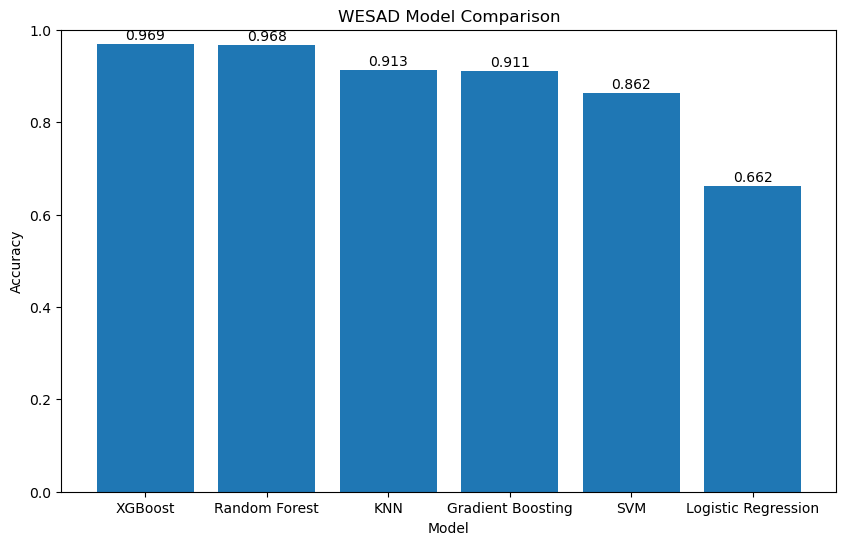

In [2]:

#this builds a graph comparing the accuracy of each model
print(results)



import matplotlib.pyplot as plt

# SORT RESULTS
sorted_results = dict(
    sorted(
        results.items(),
        key=lambda x: x[1]['accuracy'],
        reverse=True
    )
)

names = list(sorted_results.keys())
scores = [v['accuracy'] for v in sorted_results.values()]

plt.figure(figsize=(10,6))

bars = plt.bar(names, scores)

plt.ylim(0, 1)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("WESAD Model Comparison")


for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{score:.3f}",
        ha='center'
    )

plt.show()

In [3]:
#use ollama as our LLM component, this is an example of how I think we should/could use LLMs

from langchain_ollama import ChatOllama

llm = ChatOllama(model='llama3')

prompt = f'''
Analyze these WESAD emotion detection results:

{results}

Explain:
1. Which model performed best

2. What might a subject who is really stressed have as physiological data?

3. What emotion would the following sample be: 
    "eda_mean": 5.3,
    "eda_std": 1.1,
    "bvp_mean": 72.5,
    "bvp_std": 9.4,
    "temp_mean": 32.0,
    "temp_std": 0.3,
    "acc_mean": 0.9,
    "acc_std": 0.5,
    "peak_count": 9,
    "signal_entropy": 3.4


3. What emotion would the following sample be: 
    "eda_mean": 1.8,
    "eda_std": 0.2,
    "bvp_mean": 60.2,
    "bvp_std": 2.8,
    "temp_mean": 33.1,
    "temp_std": 0.1,
    "acc_mean": 0.1,
    "acc_std": 0.05,
    "peak_count": 1,
    "signal_entropy": 0.9

'''

response = llm.invoke(prompt)

print(response.content)

Based on the WESAD emotion detection results, I'll answer your questions:

**1. Which model performed best?**
The Random Forest model performed best with an accuracy of 0.9679098005203816 and F1 score of 0.9677437491166913.

**2. What might a subject who is really stressed have as physiological data?**
Physiological signals that are commonly associated with stress include:

* High skin conductance (EDA) and low variability (low EDA_std): A person under stress tends to exhibit a high level of skin conductance, which indicates increased sympathetic nervous system activity.
* Fast heart rate (BVP) and high variability: Stress can cause an increase in heart rate and a greater variation in heart rate, indicating increased arousal.
* Cooler body temperature: Stress can cause vasoconstriction, leading to decreased blood flow to the extremities and a cooler body temperature.
* Increased movement (ACC): Stress can cause restlessness and fidgeting, resulting in higher acceleration measurements.
